In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("Desktop/Projects/AgriYield_AI/datasets/soil_crop_dataset.csv")
df = pd.DataFrame(data)

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (8000, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temparature      8000 non-null   float64
 1   Humidity         8000 non-null   float64
 2   Moisture         8000 non-null   float64
 3   Soil Type        8000 non-null   object 
 4   Crop Type        8000 non-null   object 
 5   Nitrogen         8000 non-null   int64  
 6   Potassium        8000 non-null   int64  
 7   Phosphorous      8000 non-null   int64  
 8   Fertilizer Name  8000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 562.6+ KB


In [7]:
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,30.338895,59.210731,43.580862,18.429125,3.916375,18.512500
std,4.478262,8.177366,12.596156,11.852406,5.494807,13.244113
min,20.000000,40.020000,20.000000,0.000000,0.000000,0.000000
25%,27.050000,53.277500,33.967500,9.000000,0.000000,8.000000
50%,30.240000,59.110000,42.250000,14.000000,1.000000,18.000000
75%,33.460000,65.082500,52.950000,26.000000,5.000000,30.000000
max,40.000000,80.000000,70.000000,46.000000,23.000000,46.000000


In [8]:
df.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
numeric_cols = [
    "Temparature",
    "Humidity",
    "Moisture",
    "Nitrogen",
    "Potassium",
    "Phosphorous"
]

(df[numeric_cols] < 0).sum()

Temparature    0
Humidity       0
Moisture       0
Nitrogen       0
Potassium      0
Phosphorous    0
dtype: int64

In [11]:
for col in ["Soil Type", "Crop Type", "Fertilizer Name"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Soil Type
Soil Type
Clayey    1623
Black     1613
Red       1594
Loamy     1590
Sandy     1580
Name: count, dtype: int64

Crop Type
Crop Type
Sugarcane      763
Maize          753
Wheat          747
Ground Nuts    732
Pulses         728
Cotton         722
Millets        718
Tobacco        717
Oil seeds      711
Paddy          706
Barley         703
Name: count, dtype: int64

Fertilizer Name
Fertilizer Name
14-35-14    1188
Urea        1170
DAP         1167
10-26-26    1128
17-17-17    1124
28-28       1120
20-20       1103
Name: count, dtype: int64


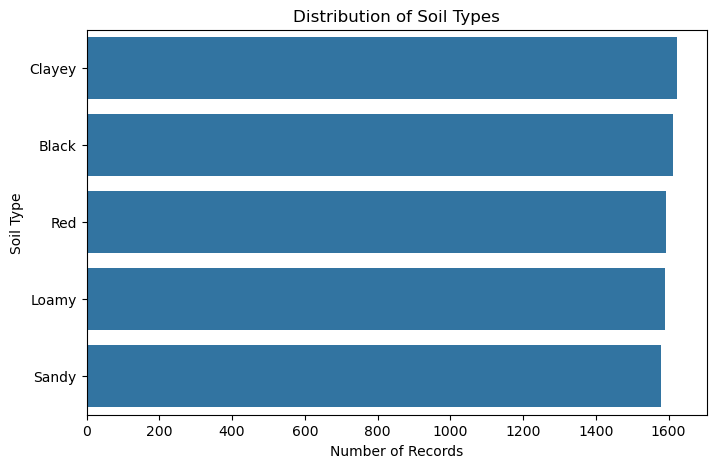

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y="Soil Type",
    order=df["Soil Type"].value_counts().index
)

plt.title("Distribution of Soil Types")
plt.xlabel("Number of Records")
plt.ylabel("Soil Type")
plt.show()

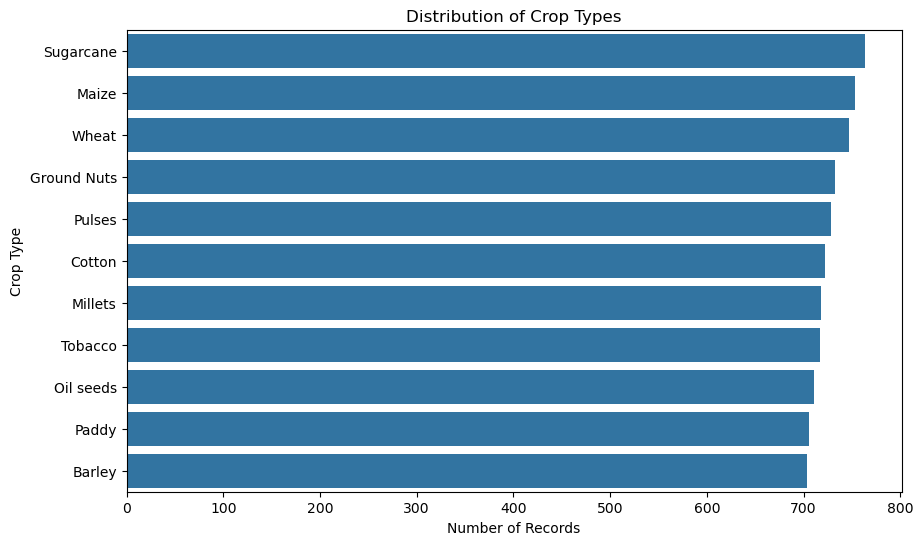

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Crop Type",
    order=df["Crop Type"].value_counts().index
)

plt.title("Distribution of Crop Types")
plt.xlabel("Number of Records")
plt.ylabel("Crop Type")
plt.show()

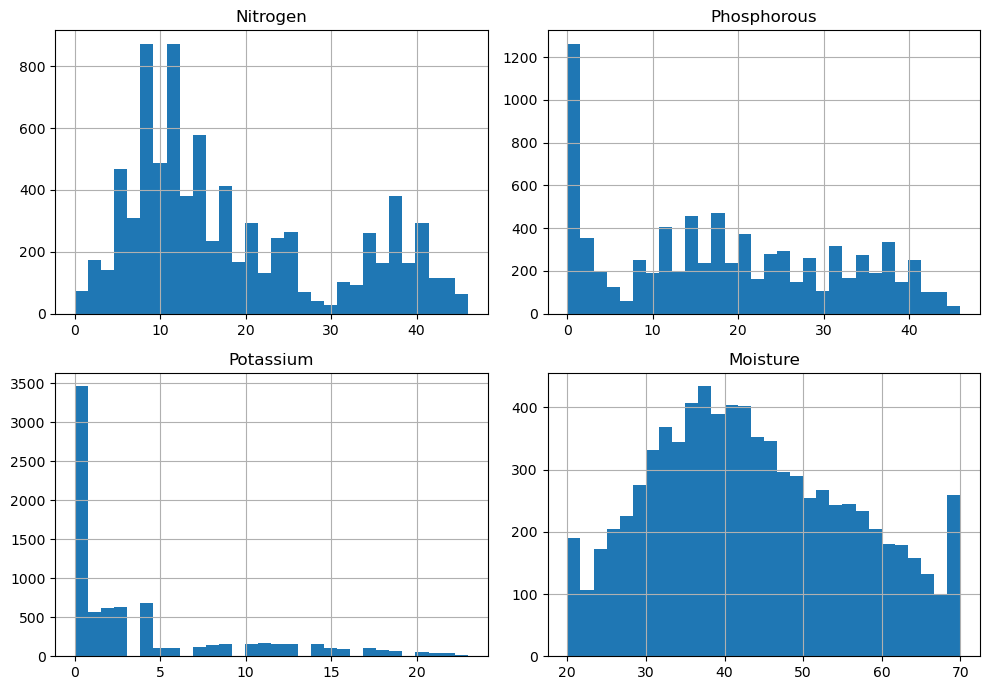

In [ ]:
#Soil & Nutrient Distributions
soil_cols = [
    "Nitrogen",
    "Phosphorous",
    "Potassium",
    "Moisture"
]

df[soil_cols].hist(
    figsize=(10, 7),
    bins=30
)

plt.tight_layout()
plt.show()

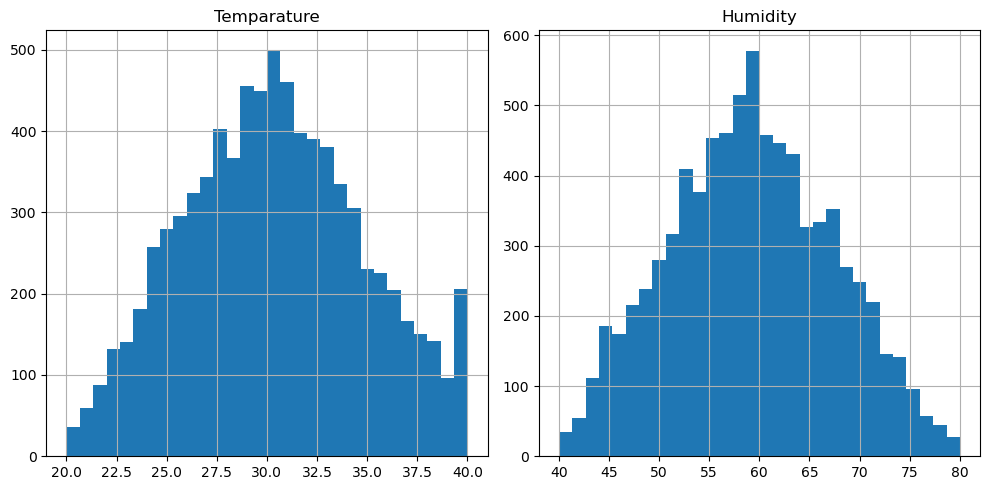

In [15]:
df[["Temparature", "Humidity"]].hist(
    figsize=(10, 5),
    bins=30
)

plt.tight_layout()
plt.show()

In [16]:
#Soil Nutrients vs Crop Type
nutrient_by_crop = (
    df.groupby("Crop Type")[
        ["Nitrogen", "Phosphorous", "Potassium"]
    ]
    .mean()
)

nutrient_by_crop

,Nitrogen,Phosphorous,Potassium
Crop Type,,,
Barley,17.870555,19.028450,3.960171
Cotton,17.984765,19.000000,3.878116
Ground Nuts,18.314208,18.467213,4.248634
Maize,18.903054,17.784861,4.138114
Millets,19.171309,17.834262,3.479109
Oil seeds,18.412096,17.749648,4.272855
Paddy,18.518414,18.745042,3.862606
Pulses,18.086538,18.906593,3.927198
Sugarcane,18.764089,18.466579,3.657929


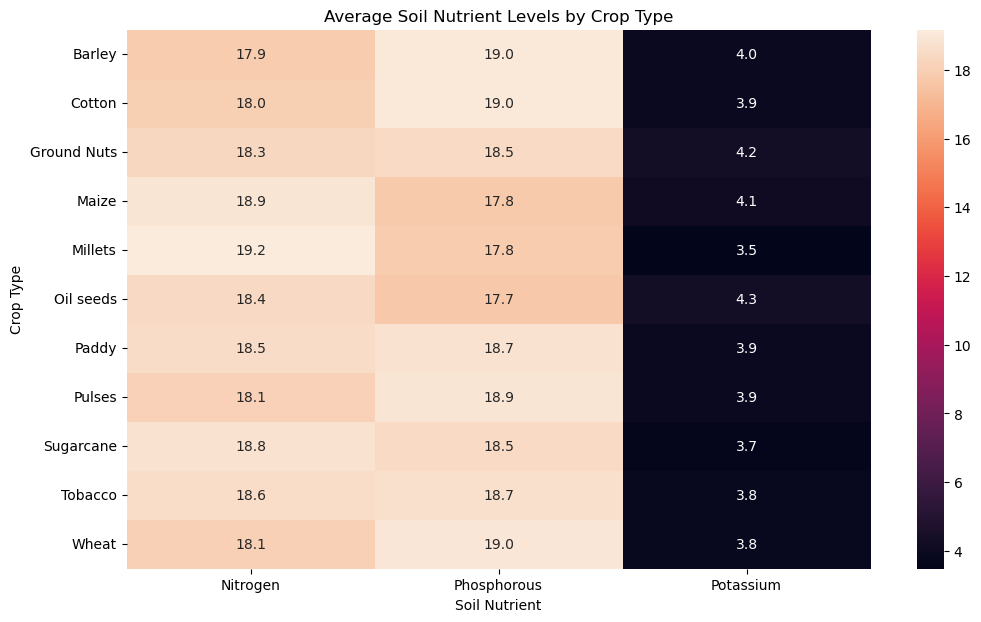

In [17]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    nutrient_by_crop,
    annot=True,
    fmt=".1f"
)

plt.title("Average Soil Nutrient Levels by Crop Type")
plt.xlabel("Soil Nutrient")
plt.ylabel("Crop Type")
plt.show()

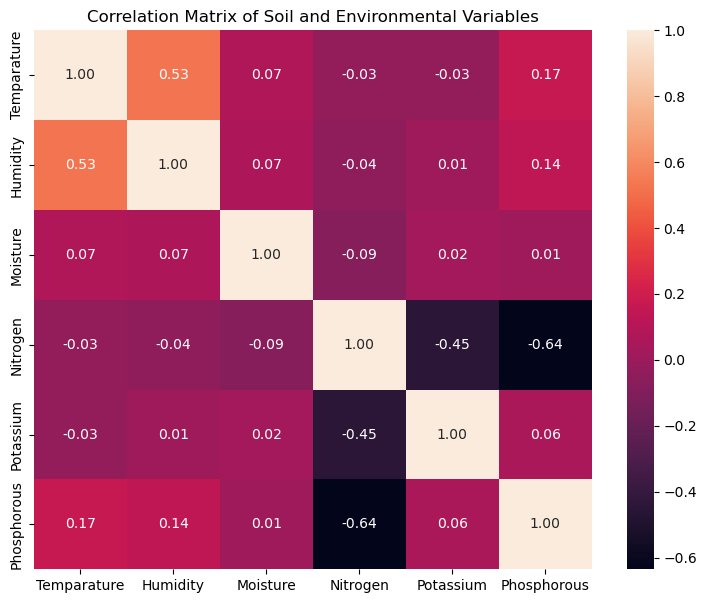

In [18]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Soil and Environmental Variables")
plt.show()

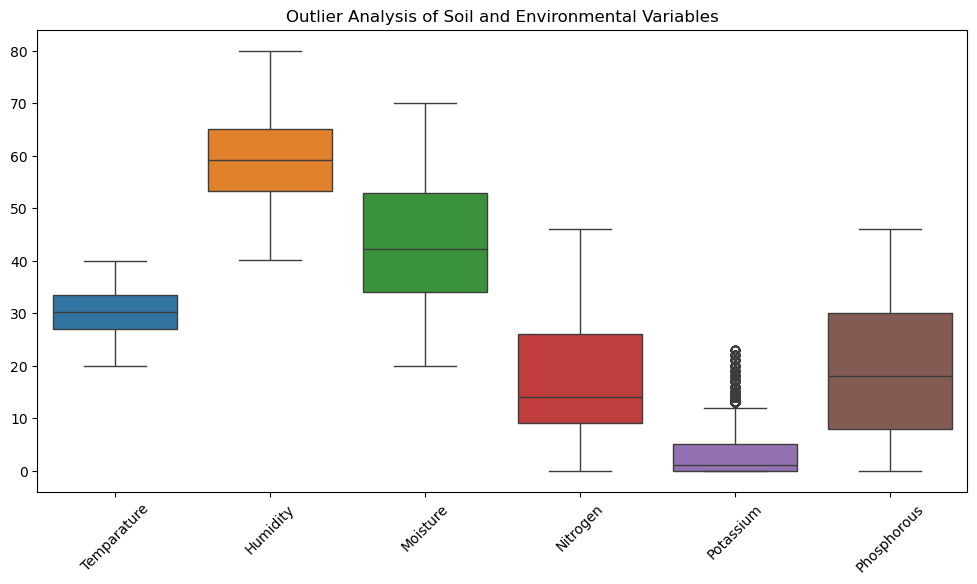

In [19]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Analysis of Soil and Environmental Variables")
plt.xticks(rotation=45)
plt.show()

In [20]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} potential outliers")

Temparature: 0 potential outliers
Humidity: 0 potential outliers
Moisture: 0 potential outliers
Nitrogen: 0 potential outliers
Potassium: 910 potential outliers
Phosphorous: 0 potential outliers


In [ ]:
# ## EDA Findings

# - The dataset contains 8,000 records and 9 attributes.
# - The dataset contains soil, environmental, crop, and fertilizer
#   information.
# - No missing values were identified.
# - No duplicate records were identified.
# - Negative-value checks were performed on the numerical variables.
# - Soil Type, Crop Type, and Fertilizer Name were analyzed as categorical
#   variables.
# - The distributions of Nitrogen, Phosphorous, Potassium, Moisture,
#   Temperature, and Humidity were examined.
# - Soil nutrient levels were compared across different crop types to
#   identify differences in nutrient requirements.
# - Correlation analysis was performed to understand relationships among
#   soil and environmental variables.
# - Potential outliers were identified using the IQR method and will be
#   investigated before any removal or transformation.
# - The soil nutrient and crop information can later contribute to the
#   soil suitability and agricultural recommendation components of
#   YieldSense AI.